# DPT Pancreas — Exploratory Notebook

This notebook:
1. Loads and preprocesses the scVelo pancreas dataset
2. Plots cells coloured by cluster in UMAP and tSNE space
3. Explains and visualises root cell selection
4. Runs standard DPT (Diffusion Pseudotime) and plots pseudotime

In [1]:
import sys
import os
from pathlib import Path

# Adjust paths so TraVeLer modules are importable
NOTEBOOK_DIR = Path(os.getcwd())
TRAVELER_ROOT = NOTEBOOK_DIR.parents[1]  # .../TraVeLer
sys.path.insert(0, str(TRAVELER_ROOT))

DATA_FILE = TRAVELER_ROOT / 'data' / 'pancreas.h5ad'

import numpy as np
import pandas as pd
import scanpy as sc
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches

sc.settings.verbosity = 1
sc.settings.set_figure_params(dpi=100, frameon=False)

## 1. Load and preprocess

In [2]:
adata = sc.read(str(DATA_FILE))
print(adata)
print('\nObs columns:', adata.obs.columns.tolist())
print('Obsm keys:  ', list(adata.obsm.keys()))

AnnData object with n_obs × n_vars = 3696 × 27998
    obs: 'clusters_coarse', 'clusters', 'S_score', 'G2M_score'
    var: 'highly_variable_genes'
    uns: 'clusters_coarse_colors', 'clusters_colors', 'day_colors', 'neighbors', 'pca'
    obsm: 'X_pca', 'X_umap'
    layers: 'spliced', 'unspliced'
    obsp: 'distances', 'connectivities'

Obs columns: ['clusters_coarse', 'clusters', 'S_score', 'G2M_score']
Obsm keys:   ['X_pca', 'X_umap']


/Users/Abhi/Desktop/TraVeLer/venv/lib/python3.9/site-packages/anndata/compat/__init__.py:329: FutureWarning: Moving element from .uns['neighbors']['distances'] to .obsp['distances'].

This is where adjacency matrices should go now.
  warn(
/Users/Abhi/Desktop/TraVeLer/venv/lib/python3.9/site-packages/anndata/compat/__init__.py:329: FutureWarning: Moving element from .uns['neighbors']['connectivities'] to .obsp['connectivities'].

This is where adjacency matrices should go now.
  warn(


In [3]:
sc.pp.filter_genes(adata, min_counts=20)
sc.pp.normalize_total(adata)
sc.pp.log1p(adata)
sc.pp.highly_variable_genes(adata)

sc.tl.pca(adata, random_state=42)
sc.pp.neighbors(adata, n_neighbors=50, n_pcs=10, random_state=42)

# Recompute UMAP (consistent with evaluation.py)
sc.tl.umap(adata, random_state=42)

# Diffmap required for DPT
sc.tl.diffmap(adata, n_comps=10)

print('Preprocessing done.')
print(adata)

/Users/Abhi/Desktop/TraVeLer/venv/lib/python3.9/site-packages/pandas/core/util/hashing.py:330: RuntimeWarning: invalid value encountered in cast
  vals.astype(str).astype(object), hash_key, encoding
/Users/Abhi/Desktop/TraVeLer/venv/lib/python3.9/site-packages/threadpoolctl.py:1226: RuntimeWarning: 
Found Intel OpenMP ('libiomp') and LLVM OpenMP ('libomp') loaded at
the same time. Both libraries are known to be incompatible and this
can cause random crashes or deadlocks on Linux when loaded in the
same Python program.
Using threadpoolctl may cause crashes or deadlocks. For more
information and possible workarounds, please see
    https://github.com/joblib/threadpoolctl/blob/master/multiple_openmp.md

  warnings.warn(msg, RuntimeWarning)


Preprocessing done.
AnnData object with n_obs × n_vars = 3696 × 12808
    obs: 'clusters_coarse', 'clusters', 'S_score', 'G2M_score'
    var: 'highly_variable_genes', 'n_counts', 'highly_variable', 'means', 'dispersions', 'dispersions_norm'
    uns: 'clusters_coarse_colors', 'clusters_colors', 'day_colors', 'neighbors', 'pca', 'log1p', 'hvg', 'umap', 'diffmap_evals'
    obsm: 'X_pca', 'X_umap', 'X_diffmap'
    varm: 'PCs'
    layers: 'spliced', 'unspliced'
    obsp: 'distances', 'connectivities'


## 2. Cells coloured by cluster

The pancreas dataset (scVelo) comes with pre-annotated `clusters` labels covering the developmental stages: Ductal, Ngn3 low EP, Ngn3 high EP, Pre-endocrine, Beta, Alpha, Delta, Epsilon.

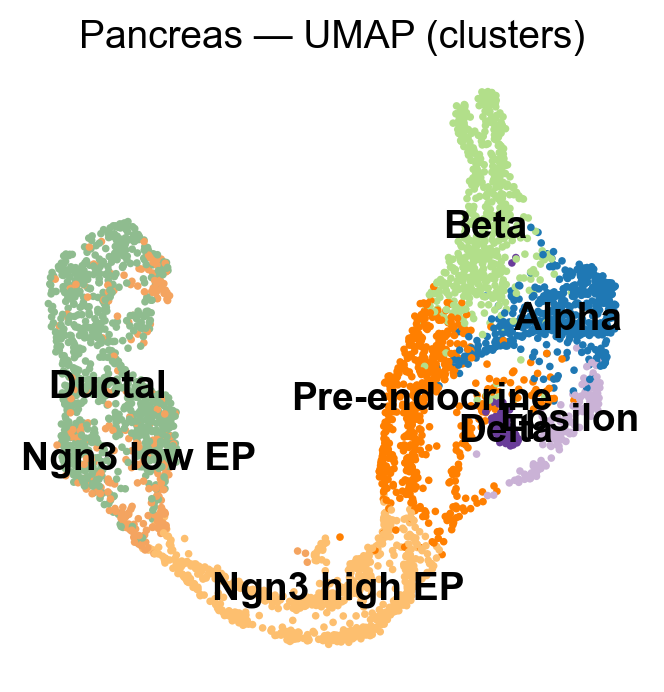

In [4]:
# UMAP coloured by cluster
sc.pl.umap(adata, color='clusters', legend_loc='on data', title='Pancreas — UMAP (clusters)',
           frameon=False, size=30)

## 3. Root cell selection

We select the root cell as the cell with the **lowest y-coordinate in tSNE space**.

**Why?**  
In the pancreas developmental trajectory, Ductal cells (the most primitive progenitors) consistently appear at the bottom of the tSNE plot. Taking `argmin(tSNE_y)` gives a reproducible anchor at the start of the lineage without requiring manual cluster labelling.

## 3. Root cell selection

We select the root cell from **UMAP space**: take the **left half** of cells (x < mean(x)), then pick the cell with the **highest UMAP y** within that subset.

**Why?**  
In the pancreas UMAP, Ductal cells (the most primitive progenitors) cluster in the left portion of the plot at the top. This heuristic is UMAP-space consistent and gives a reproducible anchor at the start of the lineage without requiring manual cluster labelling.

In [5]:
umap = adata.obsm['X_umap']

mask = umap[:, 0] < umap[:, 0].mean()
passed_indices = np.where(mask)[0]
sub_argmax = umap[mask, 1].argmax()
root = int(passed_indices[sub_argmax])

print(f'Root cell index : {root}')
print(f'UMAP coordinates: {umap[root]}')
if 'clusters' in adata.obs.columns:
    print(f'Cluster label   : {adata.obs["clusters"].iloc[root]}')

Root cell index : 732
UMAP coordinates: [-3.1114793 13.060017 ]
Cluster label   : Ductal


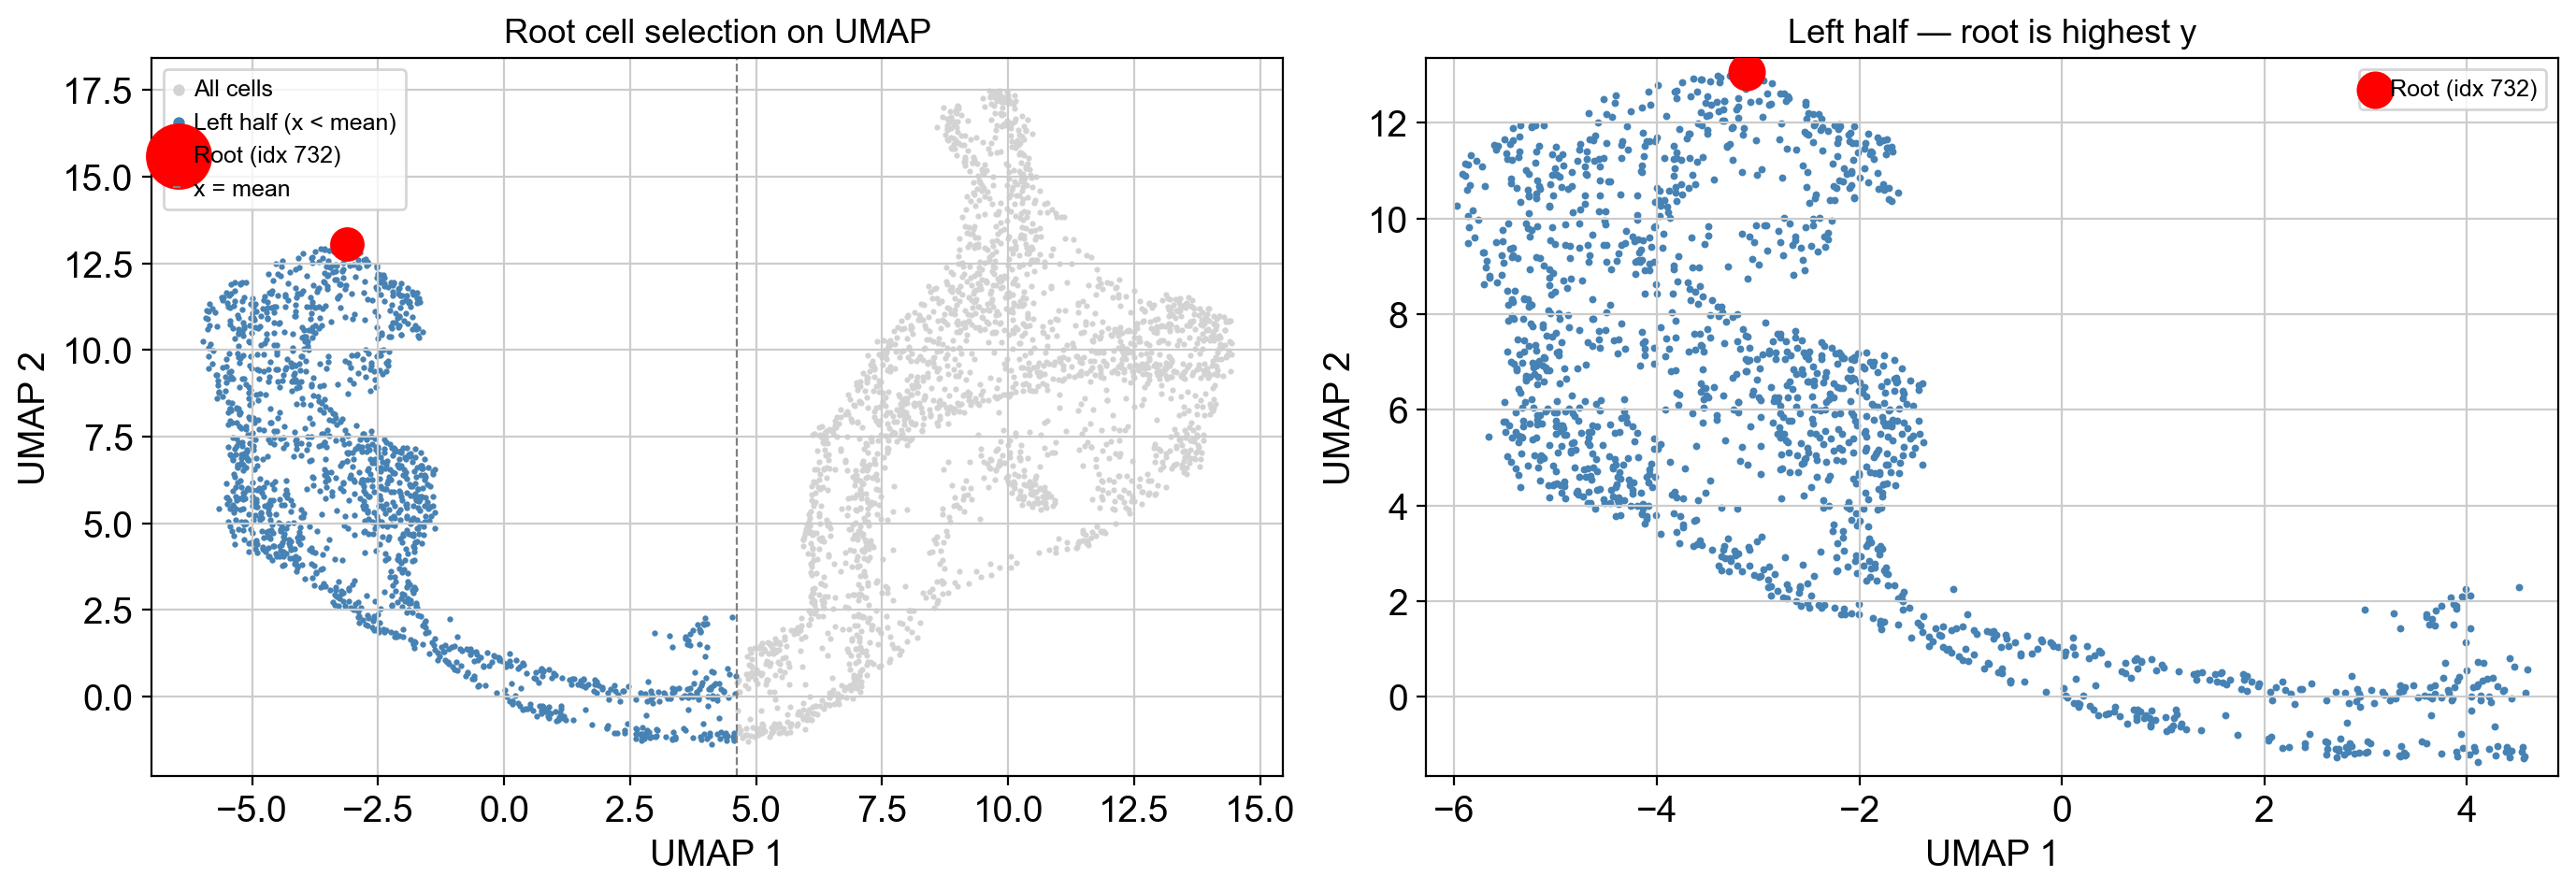

In [6]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].scatter(umap[:, 0], umap[:, 1], s=5, c='lightgrey', linewidths=0, label='All cells')
axes[0].scatter(umap[mask, 0], umap[mask, 1], s=5, c='steelblue', linewidths=0, label='Left half (x < mean)')
axes[0].scatter(umap[root, 0], umap[root, 1], s=150, c='red', zorder=6, label=f'Root (idx {root})')
axes[0].axvline(umap[:, 0].mean(), ls='--', lw=0.8, c='grey', label='x = mean')
axes[0].set_title('Root cell selection on UMAP', fontsize=13)
axes[0].set_xlabel('UMAP 1'); axes[0].set_ylabel('UMAP 2')
axes[0].legend(fontsize=9, markerscale=2)

left_umap = umap[mask]
margin = 0.3
axes[1].scatter(left_umap[:, 0], left_umap[:, 1], s=8, c='steelblue', linewidths=0)
axes[1].scatter(umap[root, 0], umap[root, 1], s=180, c='red', zorder=6, label=f'Root (idx {root})')
axes[1].set_xlim(left_umap[:, 0].min() - margin, left_umap[:, 0].max() + margin)
axes[1].set_ylim(left_umap[:, 1].min() - margin, left_umap[:, 1].max() + margin)
axes[1].set_title('Left half — root is highest y', fontsize=13)
axes[1].set_xlabel('UMAP 1'); axes[1].set_ylabel('UMAP 2')
axes[1].legend(fontsize=9)

plt.tight_layout()
plt.show()

In [8]:
adata.uns['iroot'] = root
sc.tl.dpt(adata)
print('DPT range:', adata.obs['dpt_pseudotime'].min(), '–', adata.obs['dpt_pseudotime'].max())

DPT range: 0.0 – 1.0


NameError: name 'tsne' is not defined

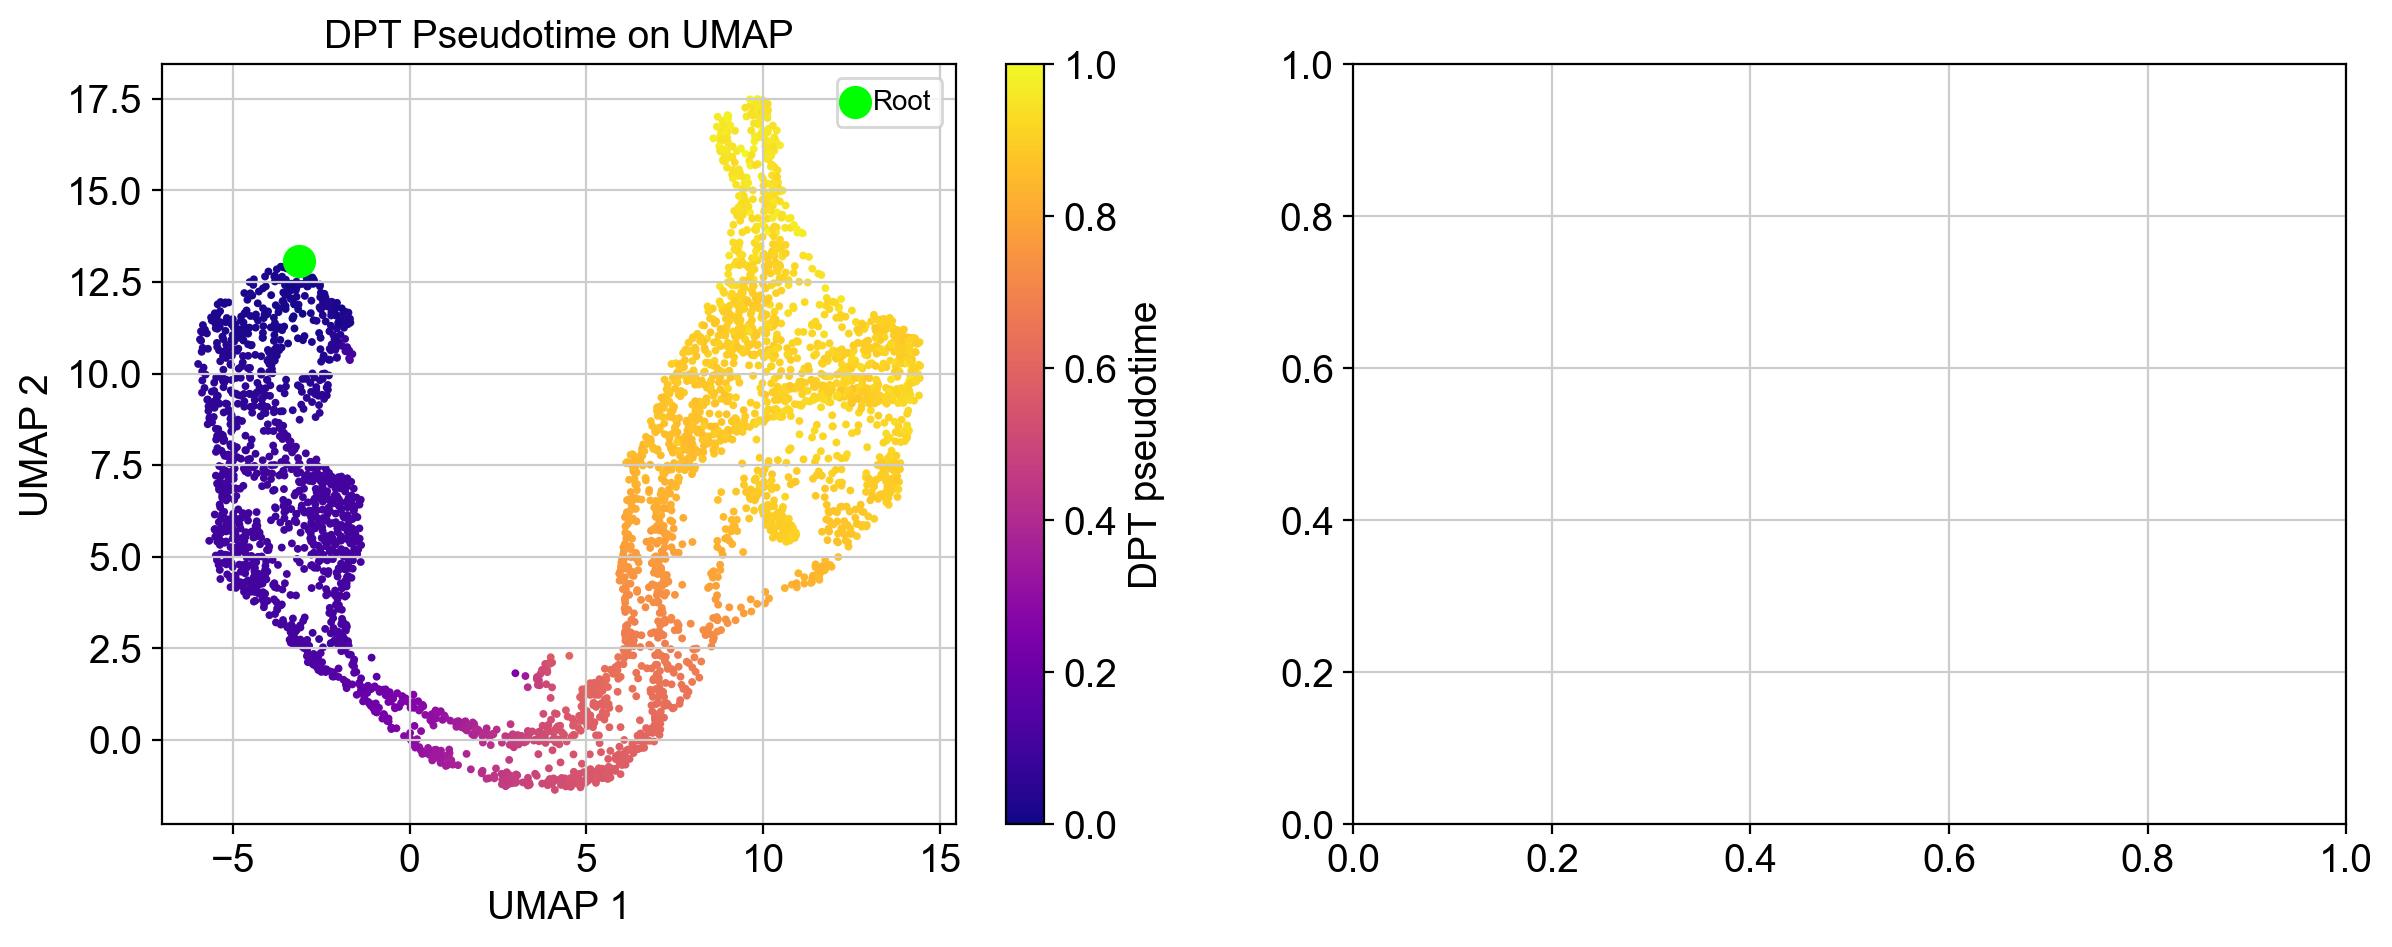

In [9]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Pseudotime on UMAP
pt = adata.obs['dpt_pseudotime'].values
sc0 = axes[0].scatter(umap[:, 0], umap[:, 1], c=pt, cmap='plasma', s=8, linewidths=0)
axes[0].scatter(umap[root, 0], umap[root, 1], s=120, c='lime', zorder=5, label='Root')
plt.colorbar(sc0, ax=axes[0], label='DPT pseudotime')
axes[0].set_title('DPT Pseudotime on UMAP', fontsize=14)
axes[0].set_xlabel('UMAP 1'); axes[0].set_ylabel('UMAP 2')
axes[0].legend(fontsize=10)

# Pseudotime on tSNE
sc1 = axes[1].scatter(tsne[:, 0], tsne[:, 1], c=pt, cmap='plasma', s=8, linewidths=0)
axes[1].scatter(tsne[root, 0], tsne[root, 1], s=120, c='lime', zorder=5, label='Root')
plt.colorbar(sc1, ax=axes[1], label='DPT pseudotime')
axes[1].set_title('DPT Pseudotime on tSNE', fontsize=14)
axes[1].set_xlabel('tSNE 1'); axes[1].set_ylabel('tSNE 2')
axes[1].legend(fontsize=10)

plt.tight_layout()
plt.show()

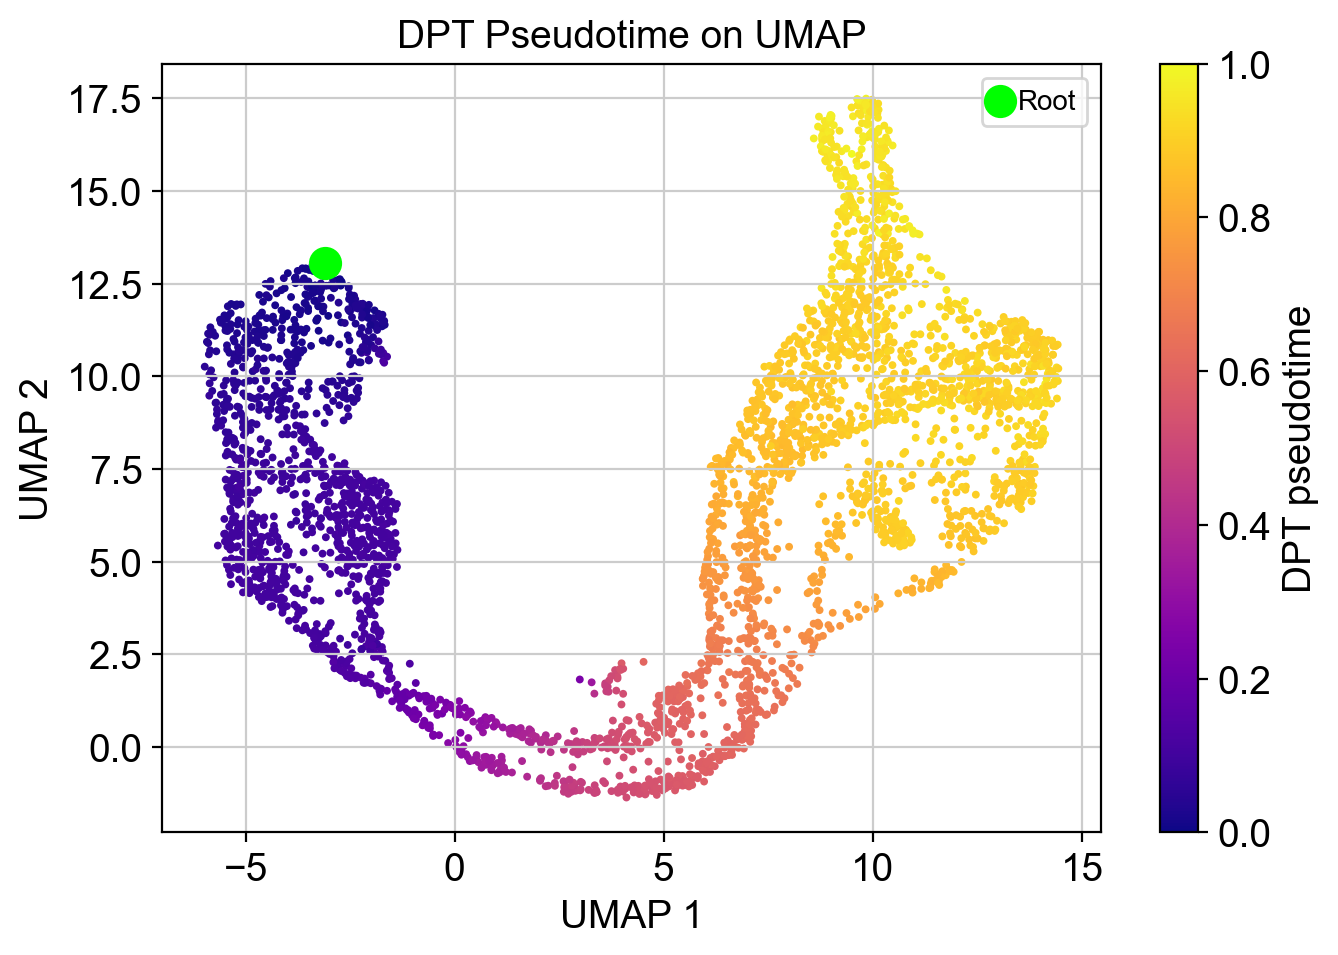

In [10]:
pt = adata.obs['dpt_pseudotime'].values

fig, ax = plt.subplots(figsize=(7, 5))
sc0 = ax.scatter(umap[:, 0], umap[:, 1], c=pt, cmap='plasma', s=8, linewidths=0)
ax.scatter(umap[root, 0], umap[root, 1], s=120, c='lime', zorder=5, label='Root')
plt.colorbar(sc0, ax=ax, label='DPT pseudotime')
ax.set_title('DPT Pseudotime on UMAP', fontsize=14)
ax.set_xlabel('UMAP 1'); ax.set_ylabel('UMAP 2')
ax.legend(fontsize=10)
plt.tight_layout()
plt.show()